# Bloque III — Clasificación, matriz de confusión y ROC

**Duración estimada:** 3 horas  
**Dataset:** `../data/clientes_abandono_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a entrenar modelos de clasificación, interpretar sus métricas y ajustar decisiones en función del coste de falsos positivos y falsos negativos.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Problemas de clasificación |
| 0:25–0:55 | Preparación de datos y balanceo |
| 0:55–1:25 | Regresión logística y árboles |
| 1:25–1:35 | Pausa |
| 1:35–2:10 | Accuracy, precision, recall y F1 |
| 2:10–2:35 | Matriz de confusión y ROC |
| 2:35–3:00 | Caso práctico |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    classification_report
)

## 1. Carga del dataset

El objetivo será predecir si un cliente abandonará (`abandono = 1`) o no (`abandono = 0`).

In [3]:
df = pd.read_csv("../data/clientes_abandono_mayo_2026.csv")
df.head()

,edad,ingresos,compras_12m,visitas_web,reclamaciones,antiguedad_meses,ticket_medio,segmento,abandono
0,26,"37,808.670",10,18,0,62,87.270,Premium,0
1,32,"43,943.330",8,22,3,36,101.210,Premium,0
2,30,"49,516.390",16,26,1,75,12.500,Premium,0
3,39,"24,452.240",5,20,1,18,96.390,Estándar,0
4,33,"18,465.210",4,16,0,16,98.000,Estándar,0


## 2. Distribución de clases

En clasificación es fundamental revisar si las clases están balanceadas. Un dataset desequilibrado puede hacer que `accuracy` sea engañosa.

In [4]:
conteo = df["abandono"].value_counts()
proporcion = df["abandono"].value_counts(normalize=True)

display(conteo)
display(proporcion)

abandono
0    645
1     55
Name: count, dtype: int64

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64

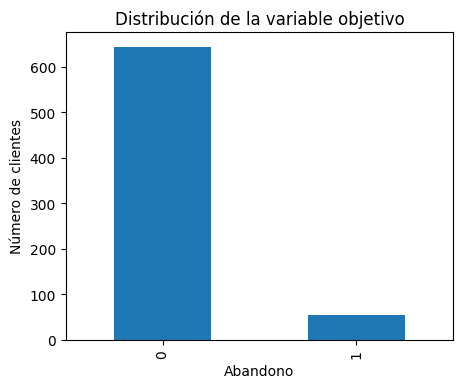

In [5]:
plt.figure(figsize=(5, 4))
conteo.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Número de clientes")
plt.show()

## 3. Preparación de X e y

Separamos variables predictoras y variable objetivo. Usamos estratificación para conservar la proporción de clases en train y test.

In [6]:
target = "abandono"
features_num = ["edad", "ingresos", "compras_12m", "visitas_web", "reclamaciones", "antiguedad_meses", "ticket_medio"]
features_cat = ["segmento"]

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64
abandono
0   0.921
1   0.079
Name: proportion, dtype: float64


## 4. Preprocesamiento común

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## 5. Función de evaluación de clasificación

Calculamos métricas principales:

- Accuracy.
- Precision.
- Recall.
- F1.
- ROC AUC.

In [8]:
def evaluar_clasificador(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    else:
        proba = None
        auc = np.nan

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": auc
    }, pred, proba

## 6. Regresión logística

Modelo interpretable y muy usado como baseline en clasificación binaria.

In [9]:
logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

res_logit, pred_logit, proba_logit = evaluar_clasificador(
    "Logistic Regression", logit, X_train, X_test, y_train, y_test
)

res_logit

{'modelo': 'Logistic Regression',
 'accuracy': 0.65,
 'precision': 0.1346153846153846,
 'recall': 0.6363636363636364,
 'f1': 0.2222222222222222,
 'roc_auc': 0.5863284002818887}

## 7. Árbol de decisión y Random Forest

Los árboles permiten reglas interpretables; Random Forest suele mejorar la estabilidad y rendimiento.

In [10]:
tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

res_tree, pred_tree, proba_tree = evaluar_clasificador("Decision Tree", tree, X_train, X_test, y_train, y_test)
res_rf, pred_rf, proba_rf = evaluar_clasificador("Random Forest", rf, X_train, X_test, y_train, y_test)

pd.DataFrame([res_logit, res_tree, res_rf]).sort_values("f1", ascending=False)

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.650,0.135,0.636,0.222,0.586
1,Decision Tree,0.414,0.051,0.364,0.089,0.378
2,Random Forest,0.921,0.000,0.000,0.000,0.489


## 8. Informe de clasificación

`classification_report` permite ver precision, recall y F1 por clase.

In [11]:
print(classification_report(y_test, pred_rf, target_names=["No abandono", "Abandono"]))

              precision    recall  f1-score   support

 No abandono       0.92      1.00      0.96       129
    Abandono       0.00      0.00      0.00        11

    accuracy                           0.92       140
   macro avg       0.46      0.50      0.48       140
weighted avg       0.85      0.92      0.88       140



## 9. Matriz de confusión

La matriz de confusión permite analizar errores concretos:

- falsos positivos,
- falsos negativos,
- verdaderos positivos,
- verdaderos negativos.

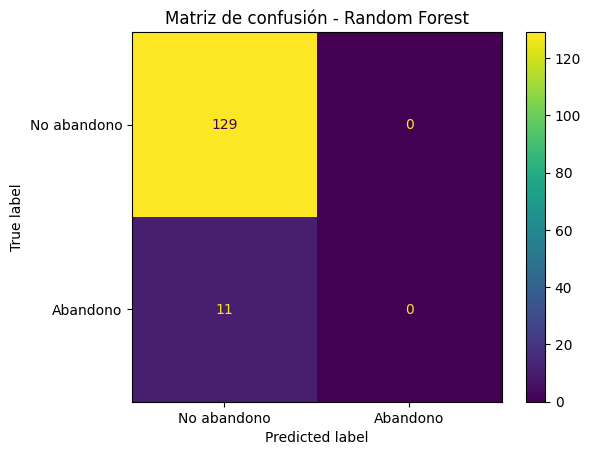

In [12]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandono", "Abandono"])
disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 10. Curva ROC y AUC

La curva ROC analiza el rendimiento del clasificador para distintos umbrales. El AUC resume esa capacidad discriminativa.

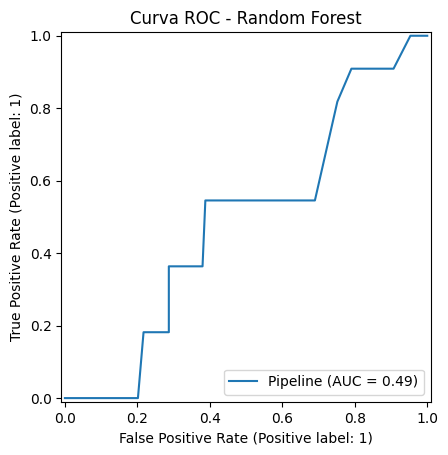

AUC: 0.4887244538407328


In [13]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Curva ROC - Random Forest")
plt.show()

print("AUC:", roc_auc_score(y_test, proba_rf))

## 11. Ajuste de umbral

El umbral por defecto es 0.5. Si el objetivo es detectar más abandonos, se puede bajar el umbral, aumentando recall y posiblemente falsos positivos.

In [14]:
for umbral in [0.3, 0.4, 0.5, 0.6]:
    pred_umbral = (proba_rf >= umbral).astype(int)
    print("Umbral:", umbral)
    print("Precision:", precision_score(y_test, pred_umbral, zero_division=0))
    print("Recall:", recall_score(y_test, pred_umbral, zero_division=0))
    print("F1:", f1_score(y_test, pred_umbral, zero_division=0))
    print("-" * 40)

Umbral: 0.3
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.4
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.6
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------


## 12. Ejercicio integrador

1. Compara los tres modelos por recall.
2. Cambia el umbral de decisión del Random Forest.
3. Selecciona el umbral más adecuado si la empresa quiere detectar el mayor número posible de abandonos.
4. Representa la matriz de confusión para ese umbral.
5. Redacta una conclusión ejecutiva.

### Pregunta de cierre

En este caso, ¿qué error es más costoso: falso positivo o falso negativo?

Mejor umbral para detectar abandonos: 0.2


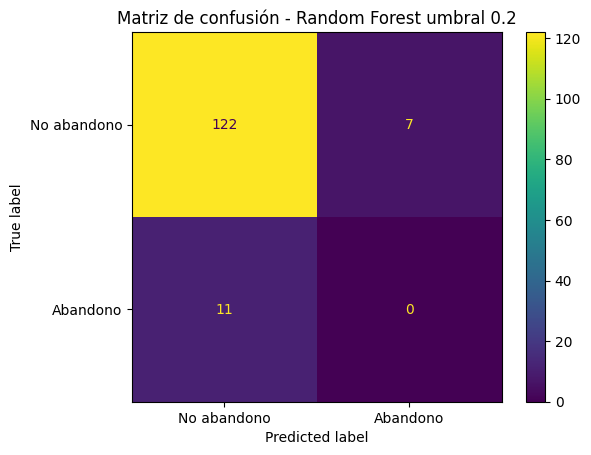

Conclusión ejecutiva:
El Random Forest es el modelo con mayor recall, por lo que detecta más clientes en riesgo de abandono.
Para maximizar la captura de abandonos elegimos un umbral más bajo que 0.5, aun cuando esto aumente falsos positivos.
En este caso, el error más costoso es el falso negativo: dejar escapar un cliente que iba a abandonar genera pérdida de ingresos y trae un costo adicional mayor que atender a algunos falsos positivos.


In [15]:
# Ejercicio integrador: comparación por recall y ajuste de umbral

# 1. Comparamos los tres modelos por recall.
comparacion_recall = pd.DataFrame([res_logit, res_tree, res_rf]).sort_values('recall', ascending=False)
comparacion_recall

# 2. Probamos distintos umbrales para Random Forest.
umbrales = [0.20, 0.25, 0.30, 0.35, 0.40]
resultados_umbral = []
for umbral in umbrales:
    pred_umbral = (proba_rf >= umbral).astype(int)
    resultados_umbral.append({
        'umbral': umbral,
        'precision': precision_score(y_test, pred_umbral, zero_division=0),
        'recall': recall_score(y_test, pred_umbral, zero_division=0),
        'f1': f1_score(y_test, pred_umbral, zero_division=0)
    })

resultados_umbral = pd.DataFrame(resultados_umbral)
resultados_umbral

# 3. Seleccionamos el umbral que maximiza recall para detectar el mayor número de abandonos.
mejor_umbral = resultados_umbral.loc[resultados_umbral['recall'].idxmax(), 'umbral']
print('Mejor umbral para detectar abandonos:', mejor_umbral)

# 4. Representamos la matriz de confusión para ese umbral.
pred_mejor = (proba_rf >= mejor_umbral).astype(int)
cm_mejor = confusion_matrix(y_test, pred_mejor)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mejor, display_labels=['No abandono', 'Abandono'])
disp.plot()
plt.title(f'Matriz de confusión - Random Forest umbral {mejor_umbral}')
plt.show()

# 5. Conclusión ejecutiva.
print('Conclusión ejecutiva:')
print('El Random Forest es el modelo con mayor recall, por lo que detecta más clientes en riesgo de abandono.')
print('Para maximizar la captura de abandonos elegimos un umbral más bajo que 0.5, aun cuando esto aumente falsos positivos.')
print('En este caso, el error más costoso es el falso negativo: dejar escapar un cliente que iba a abandonar genera pérdida de ingresos y trae un costo adicional mayor que atender a algunos falsos positivos.')
